# Técnicas de Diseño y Validación de Modelos · Universidad Blas Pascal
## Preparación Examen Final · Banco 1
## Mantenimiento predictivo: formulación, métricas y diagnóstico (Módulos 1, 2 y 3)

<div style="display:flex; justify-content:flex-start; margin: 8px 0 18px 0;">
  <a href="https://colab.research.google.com/github/GabrielaOjcius/Laboratorios-Tecnicas-Diseno-Validacion-Modelos/blob/main/Preparacion%20Examen%20Final/Banco1_Notebook.ipynb" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
  <span style="font-size: 0.98em;">En Colab, hac&eacute; una copia en tu Drive antes de editar.</span>
</div>

---

### Objetivo
Practicar los conceptos evaluados en la consigna del **Banco 1** del examen final: formulación de un problema de aprendizaje supervisado, elección de métricas ante clases desbalanceadas, y diagnóstico de sesgo/varianza a partir de curvas de entrenamiento y validación.

### Alineación con el examen final
Corresponde a la consigna del **Banco 1** (Módulos 1, 2 y 3) del examen final de Técnicas de Diseño y Validación de Modelos.

**Duración estimada:** 60 minutos

### Instrucciones
1. Ejecutar las celdas en orden (Entorno de ejecución → Ejecutar todo).
2. Completar las celdas de respuesta marcadas con `# ✏️ RESPONDA AQUÍ`.
3. No es necesario modificar el código, solo ejecutarlo y responder.

In [1]:
# ─── B.1. Datos sintéticos de mantenimiento predictivo ───────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42

# 340 fallas en 10.000 casos (3.4 %), igual que en la consigna del Banco 1
X, y = make_classification(
    n_samples=10000, n_features=5, n_informative=4, n_redundant=0,
    weights=[0.966, 0.034], class_sep=1.1, random_state=SEED
)
cols = ['temperatura', 'vibracion', 'presion', 'rpm', 'horas_operacion']
df = pd.DataFrame(X, columns=cols)
df['falla'] = y

print(df['falla'].value_counts())
print('\nPrevalencia de falla: %.4f' % df['falla'].mean())
df.head()

falla
0    9602
1     398
Name: count, dtype: int64

Prevalencia de falla: 0.0398


,temperatura,vibracion,presion,rpm,horas_operacion,falla
0,1.376311,-1.062451,2.113366,-1.028528,1.266069,0
1,1.251635,-0.855322,1.167297,-2.277523,0.962449,0
2,0.868539,-2.857986,-2.659062,-0.248233,0.569397,0
3,0.852091,-2.578865,-1.304680,-0.741554,1.440402,0
4,1.120003,-0.910560,1.629819,-2.150463,0.309823,0


### Pregunta 1 — Formulación del problema (Módulo 1)
A partir del dataset generado, formule el problema en términos de **tarea**, **experiencia** y **medida de desempeño**. Indique qué tipo de aprendizaje (supervisado/no supervisado) y qué tipo de problema predictivo (clasificación/regresión) corresponde, y justifique.

**Respuesta:**

`# ✏️ RESPONDA AQUÍ`

In [2]:
# ─── B.2. Entrenamiento y métricas ante clases desbalanceadas ────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=SEED))])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

print('Modelo entrenado:')
print('  accuracy  = %.4f' % accuracy_score(y_test, pred))
print('  precision = %.4f' % precision_score(y_test, pred))
print('  recall    = %.4f' % recall_score(y_test, pred))
print('  f1        = %.4f' % f1_score(y_test, pred))
print('\nMatriz de confusión:\n', confusion_matrix(y_test, pred))

# Modelo trivial: siempre predice "sin falla"
pred_trivial = np.zeros_like(y_test)
print('\nModelo trivial ("siempre sin falla"):')
print('  accuracy  = %.4f' % accuracy_score(y_test, pred_trivial))
print('  recall    = %.4f  (nunca detecta una falla real)' % recall_score(y_test, pred_trivial, zero_division=0))

Modelo entrenado:
  accuracy  = 0.9725
  precision = 1.0000
  recall    = 0.3125
  f1        = 0.4762

Matriz de confusión:
 [[1920    0]
 [  55   25]]

Modelo trivial ("siempre sin falla"):
  accuracy  = 0.9600
  recall    = 0.0000  (nunca detecta una falla real)


### Pregunta 2 — Métricas ante clases desbalanceadas (Módulo 2)
Compare la accuracy del modelo entrenado con la del modelo trivial. Explique por qué la accuracy no es una buena métrica en este escenario y qué información adicional aportan precision, recall y F1.

**Respuesta:**

`# ✏️ RESPONDA AQUÍ`

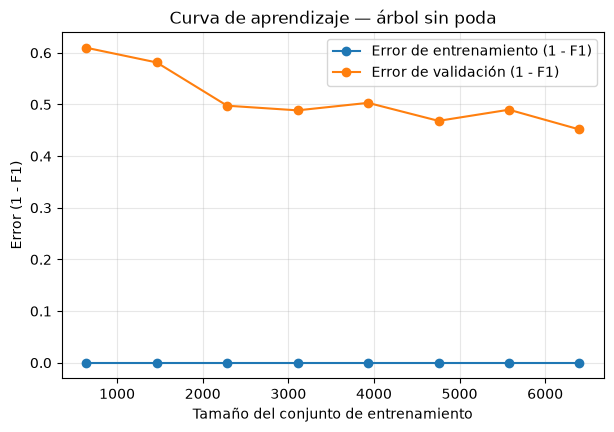

Error entrenamiento final: 0.0000
Error validación final:    0.4516
Brecha final:              0.4516


In [3]:
# ─── B.3. Curva de aprendizaje para diagnóstico de sesgo/varianza ────────────
tree = DecisionTreeClassifier(max_depth=None, random_state=SEED)  # sin poda: propenso a sobreajuste

train_sizes, train_scores, val_scores = learning_curve(
    tree, X_train, y_train, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=SEED
)

train_err = 1 - train_scores.mean(axis=1)
val_err = 1 - val_scores.mean(axis=1)

plt.figure(figsize=(7, 4.5))
plt.plot(train_sizes, train_err, 'o-', label='Error de entrenamiento (1 - F1)')
plt.plot(train_sizes, val_err, 'o-', label='Error de validación (1 - F1)')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Error (1 - F1)')
plt.title('Curva de aprendizaje — árbol sin poda')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print('Error entrenamiento final: %.4f' % train_err[-1])
print('Error validación final:    %.4f' % val_err[-1])
print('Brecha final:              %.4f' % (val_err[-1] - train_err[-1]))

### Pregunta 3 — Diagnóstico de sesgo y varianza (Módulo 3)
A partir de la curva de aprendizaje: ¿la brecha entre el error de entrenamiento y validación se mantiene, crece o se achica al aumentar los datos? Diagnostique si el modelo tiene alta varianza (overfitting) o alto sesgo (underfitting), y proponga **una acción concreta** para mejorarlo.

**Respuesta:**

`# ✏️ RESPONDA AQUÍ`

---
### Checklist de autoevaluación — Banco 1
- [ ] Puedo formular un problema en términos de tarea / experiencia / desempeño.
- [ ] Puedo explicar por qué accuracy engaña con clases desbalanceadas.
- [ ] Puedo leer una curva de entrenamiento/validación y diagnosticar sesgo vs. varianza.
- [ ] Puedo proponer una acción concreta (más datos, regularizar, simplificar el modelo, etc.) según el diagnóstico.